# Candidate Pool — Exploratory Data Analysis
Load the entire `candidates.jsonl` into memory for interactive exploration.

In [1]:
import json
import pandas as pd
from pathlib import Path

CANDIDATES_PATH = Path('challenge_dataset/candidates.jsonl') #the data directory has not been committed to Github due to its size.

# Read every line into a list of dicts
records = []
with CANDIDATES_PATH.open('r', encoding='utf-8') as fh:
    for line in fh:
        line = line.strip()
        if line:
            records.append(json.loads(line))

print(f'Loaded {len(records):,} candidates')
print(f'Keys in records: {list(records[0].keys())}')

Loaded 100,000 candidates
Keys in records: ['candidate_id', 'profile', 'career_history', 'education', 'skills', 'certifications', 'languages', 'redrob_signals']


In [2]:
# Inspecting dictionary structure.
import pprint
pprint.pprint(records[0])

{'candidate_id': 'CAND_0000001',
 'career_history': [{'company': 'Mindtree',
                     'company_size': '10001+',
                     'description': 'Implemented streaming data pipelines on '
                                    'Kafka and Spark Streaming for a real-time '
                                    'user-activity processing platform. '
                                    'Designed the schema-registry integration, '
                                    'the watermark/state management approach, '
                                    'and the deduplication logic for '
                                    'late-arriving events. Worked closely with '
                                    'the data science team to make sure '
                                    'feature pipelines aligned with what their '
                                    'models needed. Most of my career has been '
                                    'data engineering, with some adjacent ML '
              

In [3]:
# Count of all unique current_title values across the dataset
from collections import Counter

title_counts = Counter(
    c['profile'].get('current_title', '').strip()
    for c in records
    if c.get('profile', {}).get('current_title')
)

# Convert to a sorted DataFrame (most common first)
df_titles = (
    pd.DataFrame(title_counts.most_common(), columns=['Title', 'Count'])
    .reset_index(drop=True)
)
df_titles.index += 1

print(f'Unique titles: {len(df_titles):,}')
df_titles.head(len(df_titles))


Unique titles: 47


,Title,Count
1,Business Analyst,5833
2,HR Manager,5830
3,Mechanical Engineer,5791
4,Accountant,5764
5,Project Manager,5754
6,Customer Support,5750
7,Operations Manager,5744
8,Content Writer,5727
9,Sales Executive,5713
10,Civil Engineer,5702


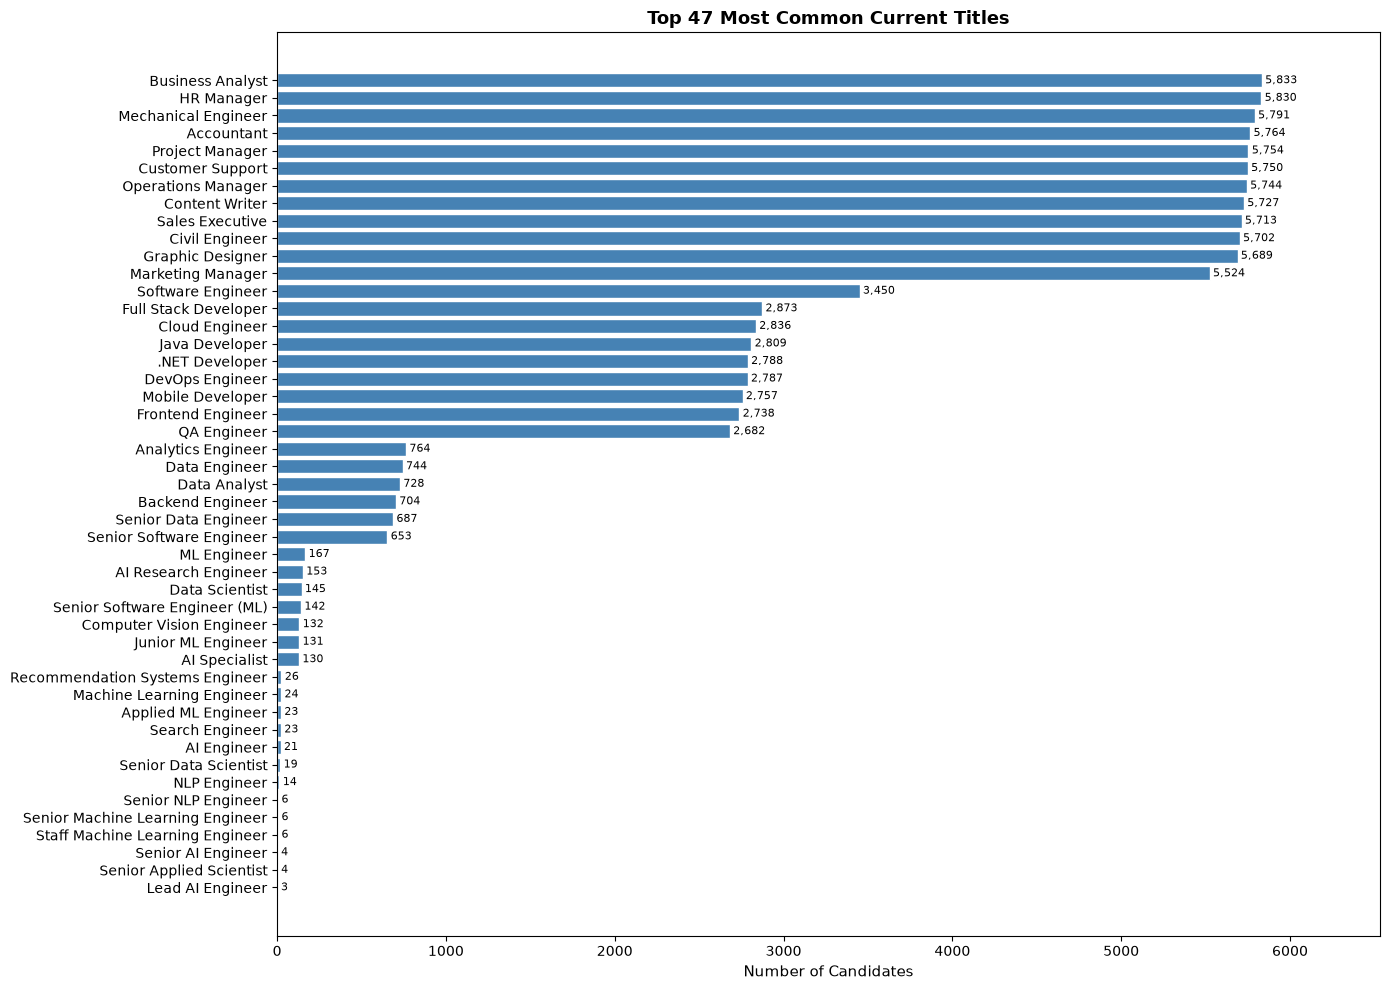

In [4]:
#Bar chart:most common current titles
import matplotlib.pyplot as plt

TOP = 47
top_df = df_titles.head(TOP)

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(top_df['Title'][::-1], top_df['Count'][::-1], color='steelblue', edgecolor='white')

# Label each bar with its count
for bar, val in zip(bars, top_df['Count'][::-1]):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=8)

ax.set_xlabel('Number of Candidates', fontsize=11)
ax.set_title(f'Top {TOP} Most Common Current Titles', fontsize=13, fontweight='bold')
ax.set_xlim(0, top_df['Count'].max() * 1.12)
plt.tight_layout()
plt.show()


In [6]:
from collections import Counter

skill_counts = Counter(
    s.get('name', '').strip()
    for c in records
    for s in c.get('skills', [])
    if s.get('name', '').strip()
)

all_skills = [skill for skill, count in skill_counts.most_common()]

print(f'Total unique skills: {len(all_skills)}\n')
for i, skill in enumerate(all_skills, 1):
    print(f'{i:>4}. {skill}')

Total unique skills: 133

   1. HTML
   2. Databricks
   3. Redux
   4. Terraform
   5. Angular
   6. Figma
   7. Salesforce CRM
   8. Vue.js
   9. Sales
  10. Accounting
  11. Agile
  12. Kafka
  13. Excel
  14. BigQuery
  15. CI/CD
  16. Project Management
  17. Airflow
  18. AWS
  19. Flask
  20. Scrum
  21. Illustrator
  22. Kubernetes
  23. ETL
  24. CSS
  25. Docker
  26. Next.js
  27. Apache Beam
  28. Java
  29. Go
  30. TypeScript
  31. JavaScript
  32. dbt
  33. REST APIs
  34. Spark
  35. Marketing
  36. Tally
  37. GraphQL
  38. Snowflake
  39. Webpack
  40. Six Sigma
  41. SEO
  42. SAP
  43. GCP
  44. PostgreSQL
  45. Rust
  46. Apache Flink
  47. gRPC
  48. Content Writing
  49. SQL
  50. Hadoop
  51. Redis
  52. Tailwind
  53. Photoshop
  54. FastAPI
  55. Microservices
  56. PowerPoint
  57. Spring Boot
  58. Data Pipelines
  59. Django
  60. MongoDB
  61. Node.js
  62. Azure
  63. React
  64. Hugging Face Transformers
  65. LangChain
  66. Information Retrieval
  67. 